# Ablation Study
**Goal:** Remove or modify one component at a time and measure the impact on ADE.

Three ablation axes:
1. **Architecture** — what does each component contribute?
2. **Features** — which input features are actually necessary?
3. **Data quantity** — how does performance scale with training set size?

> Run cells in order. Do NOT pre-fill the summary — fill it in after all cells complete.

In [48]:
# ── Setup ─────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "cartopy", "seaborn", "-q"], capture_output=True)

import os, sys
from pathlib import Path

REPO = "https://github.com/Thiruvikraman07/ClimateChangeFinalProject"
ROOT = Path("/content/ClimateChangeFinalProject")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(ROOT), "pull"], check=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TestData/TCND_test")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import importlib, src.data.dataset, src.models.lstm_seq2seq, src.training.trainer, src.training.metrics
for m in [src.data.dataset, src.models.lstm_seq2seq, src.training.trainer, src.training.metrics]:
    importlib.reload(m)

from src.data.dataset import TCTrackDataset, BASINS, BASIN2IDX
from src.data.utils import TRAIN_YEARS, VAL_YEARS, TEST_YEARS
from src.models.lstm_seq2seq import LSTMSeq2Seq, LSTMSeq2SeqAttn
from src.training.trainer import Trainer
from src.training.metrics import evaluate_dataset, evaluate_by_basin

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
(RESULTS / "checkpoints").mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASIN_COLORS = {"EP":"#2563eb","NA":"#dc2626","NI":"#d97706","SI":"#16a34a","SP":"#7c3aed","WP":"#0891b2"}
print("Device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [49]:
# Load datasets
train_ds = TCTrackDataset(DATA_ROOT, train_years=TRAIN_YEARS, cache_dir="/content")
val_ds   = TCTrackDataset(DATA_ROOT, train_years=VAL_YEARS,   cache_dir="/content")
test_ds  = TCTrackDataset(DATA_ROOT, train_years=TEST_YEARS,  cache_dir="/content")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Loading dataset from cache: tcdataset_9c99a2d89e.pkl
  6805 samples loaded instantly.
Loading dataset from cache: tcdataset_27e4d1eb3b.pkl
  1697 samples loaded instantly.
Loading dataset from cache: tcdataset_6be8e1b131.pkl
  2242 samples loaded instantly.
Train: 6805 | Val: 1697 | Test: 2242


In [50]:
# ── Generic runner ──────────────────────────────────────────────────────
def run_variant(model, name, t_ds=None, max_epochs=60, patience=10):
    """Train model variant, return test ADE per basin."""
    t_ds = t_ds or train_ds
    tl   = DataLoader(t_ds,    batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
    vl   = DataLoader(val_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    tstl = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    trainer = Trainer(model, tl, vl, DEVICE, lr=1e-3, max_epochs=max_epochs, patience=patience,
                      save_dir=str(RESULTS/"checkpoints"), experiment_name=f"abl_{name}")
    trainer.train(verbose=False)
    trainer.load_best()
    m = evaluate_by_basin(model, tstl, DEVICE)
    mean_ade = np.mean([v["ade_km"] for v in m.values()])
    print(f"  {name}: mean ADE = {mean_ade:.1f} km")
    return m

results = {}   # name -> basin_metrics dict

## Part 1 — Architecture Ablation

| Variant | What changes |
|---|---|
| `no_basin_no_attn` | Plain LSTM seq2seq, no conditioning |
| `basin_only` | Add basin embedding, no attention |
| `attn_only` | Add attention, no basin embedding |
| `full` | Basin embedding + attention (main model) |
| `deep` | Main model with 3 LSTM layers instead of 2 |
| `wide` | Main model with hidden_dim=256 instead of 128 |

In [51]:
arch_configs = {
    "no_basin_no_attn": dict(cls=LSTMSeq2Seq,     kwargs=dict(obs_feat_dim=6, hidden_dim=128, pred_len=4, n_basins=0, num_layers=2)),
    "basin_only":       dict(cls=LSTMSeq2Seq,     kwargs=dict(obs_feat_dim=6, hidden_dim=128, pred_len=4, n_basins=6, basin_emb_dim=16, num_layers=2)),
    "attn_only":        dict(cls=LSTMSeq2SeqAttn, kwargs=dict(obs_feat_dim=6, hidden_dim=128, pred_len=4, n_basins=0, num_layers=2)),
    "full":             dict(cls=LSTMSeq2SeqAttn, kwargs=dict(obs_feat_dim=6, hidden_dim=128, pred_len=4, n_basins=6, basin_emb_dim=16, num_layers=2)),
    "deep_3layers":     dict(cls=LSTMSeq2SeqAttn, kwargs=dict(obs_feat_dim=6, hidden_dim=128, pred_len=4, n_basins=6, basin_emb_dim=16, num_layers=3)),
    "wide_256":         dict(cls=LSTMSeq2SeqAttn, kwargs=dict(obs_feat_dim=6, hidden_dim=256, pred_len=4, n_basins=6, basin_emb_dim=16, num_layers=2)),
}

print("=== Architecture Ablation ===")
for name, cfg in arch_configs.items():
    model = cfg["cls"](**cfg["kwargs"]).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n[{name}] {n_params:,} params")
    results[f"arch_{name}"] = run_variant(model, f"arch_{name}")

=== Architecture Ablation ===

[no_basin_no_attn] 401,666 params

Training: abl_arch_no_basin_no_attn
  Device: cuda
  Params: 401,666
  Train batches: 27, Val batches: 7

Early stopping at epoch 47 (best=37)

Training complete. Best val_loss=0.01200 at epoch 37
Loaded best model from epoch 37 (val_loss=0.01200)
  arch_no_basin_no_attn: mean ADE = 875.0 km

[basin_only] 418,146 params

Training: abl_arch_basin_only
  Device: cuda
  Params: 418,146
  Train batches: 27, Val batches: 7

Early stopping at epoch 25 (best=15)

Training complete. Best val_loss=0.01276 at epoch 15
Loaded best model from epoch 15 (val_loss=0.01276)
  arch_basin_only: mean ADE = 948.0 km

[attn_only] 434,819 params

Training: abl_arch_attn_only
  Device: cuda
  Params: 434,819
  Train batches: 27, Val batches: 7

Early stopping at epoch 54 (best=44)

Training complete. Best val_loss=0.01203 at epoch 44
Loaded best model from epoch 44 (val_loss=0.01203)
  arch_attn_only: mean ADE = 871.7 km

[full] 451,299 params

In [52]:
# Print architecture ablation table
print("\n=== Architecture Ablation — Test ADE (km) ===")
print(f"{'Variant':<22} {'EP':>7} {'NA':>7} {'NI':>7} {'SI':>7} {'SP':>7} {'WP':>7} {'Mean':>7}")
print("-" * 76)
for name in arch_configs:
    key = f"arch_{name}"
    if key not in results: continue
    vals = [results[key].get(b, {}).get("ade_km", float("nan")) for b in BASINS]
    mean = np.nanmean(vals)
    row  = f"{name:<22}" + "".join(f" {v:>7.1f}" for v in vals) + f" {mean:>7.1f}"
    print(row)


=== Architecture Ablation — Test ADE (km) ===
Variant                     EP      NA      NI      SI      SP      WP    Mean
----------------------------------------------------------------------------
no_basin_no_attn         623.4  1113.8   522.9   884.9  1345.2   759.7   875.0
basin_only               717.0  1243.3   528.5   948.1  1446.9   804.3   948.0
attn_only                608.2  1105.1   506.6   893.3  1367.1   750.1   871.7
full                     653.9  1278.4   549.3   926.1  1349.9   812.7   928.4
deep_3layers             600.6  1111.1   429.6   919.3  1683.3   802.9   924.5
wide_256                 619.1  1167.2   518.7   904.4  1308.8   769.8   881.3


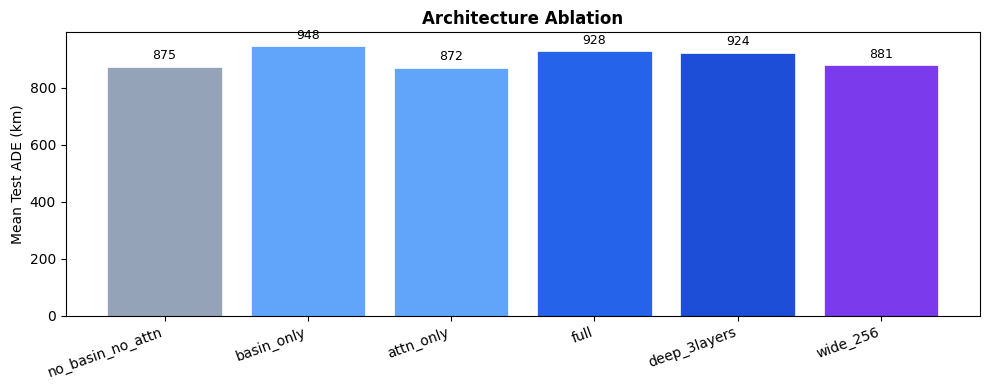

In [53]:
# Architecture ablation bar chart
fig, ax = plt.subplots(figsize=(10, 4))
names = list(arch_configs.keys())
means = [np.nanmean([results.get(f"arch_{n}",{}).get(b,{}).get("ade_km",np.nan) for b in BASINS])
         for n in names]
colors = ["#94a3b8","#60a5fa","#60a5fa","#2563eb","#1d4ed8","#7c3aed"]
bars = ax.bar(names, means, color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, labels=[f"{v:.0f}" for v in means], padding=3, fontsize=9)
ax.set_ylabel("Mean Test ADE (km)")
ax.set_title("Architecture Ablation", fontsize=12, fontweight="bold")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(RESULTS / "fig_arch_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 2 — Feature Ablation

We zero out specific input features to see what the model relies on.

**Absolute features (obs):**

| Variant | Features zeroed |
|---|---|
| `all_features` | Nothing zeroed — full baseline |
| `no_pressure` | Pressure = 0 |
| `no_wind` | Wind speed = 0 |
| `track_only` | Pressure = 0, Wind = 0 (lon+lat only) |

**Relative features (obs_rel) — motivated by nb_01 finding that Δlon+Δlat = 88.8% of gradient importance:**

| Variant | Features zeroed |
|---|---|
| `no_rel` | Δlon = 0, Δlat = 0 — removes the dominant signal |
| `rel_only` | lon = 0, lat = 0, pres = 0, wind = 0 — motion only, no absolute position |

In [54]:
class ZeroMaskDataset(Dataset):
    """Zeroes out selected obs and/or obs_rel feature columns."""
    def __init__(self, base_ds, zero_obs_cols=None, zero_rel_cols=None):
        """
        zero_obs_cols : list of column indices in obs to zero (0=lon,1=lat,2=pres,3=wind)
        zero_rel_cols : list of column indices in obs_rel to zero (0=Δlon, 1=Δlat)
        """
        self.base = base_ds
        self.zero_obs_cols = zero_obs_cols or []
        self.zero_rel_cols = zero_rel_cols or []

    def __len__(self): return len(self.base)

    def __getitem__(self, idx):
        item = {k: v.clone() if torch.is_tensor(v) else v for k, v in self.base[idx].items()}
        if self.zero_obs_cols:
            item["obs"] = item["obs"].clone()
            item["obs"][:, self.zero_obs_cols] = 0.0
        if self.zero_rel_cols:
            item["obs_rel"] = item["obs_rel"].clone()
            item["obs_rel"][:, self.zero_rel_cols] = 0.0
        return item

# (obs_cols_to_zero, rel_cols_to_zero)
feat_configs = {
    "all_features":  ([], []),
    "no_pressure":   ([2], []),
    "no_wind":       ([3], []),
    "track_only":    ([2, 3], []),         # abs: lon+lat only, rel: intact
    "no_rel":        ([], [0, 1]),         # ← KEY: removes Δlon+Δlat (88.8% of importance per nb_01)
    "rel_only":      ([0, 1, 2, 3], []),   # zero all abs — motion increments only
}

print("=== Feature Ablation ===")
for name, (obs_cols, rel_cols) in feat_configs.items():
    t_ds   = ZeroMaskDataset(train_ds, obs_cols, rel_cols)
    v_ds   = ZeroMaskDataset(val_ds,   obs_cols, rel_cols)
    tst_ds = ZeroMaskDataset(test_ds,  obs_cols, rel_cols)

    model = LSTMSeq2SeqAttn(obs_feat_dim=6, hidden_dim=128, pred_len=4,
                             n_basins=6, basin_emb_dim=16, num_layers=2).to(DEVICE)

    tl   = DataLoader(t_ds,   batch_size=256, shuffle=True,  num_workers=2)
    vl_f = DataLoader(v_ds,   batch_size=256, shuffle=False, num_workers=2)
    tstl = DataLoader(tst_ds, batch_size=256, shuffle=False, num_workers=2)

    trainer = Trainer(model, tl, vl_f, DEVICE, lr=1e-3, max_epochs=60, patience=10,
                      save_dir=str(RESULTS/"checkpoints"), experiment_name=f"abl_feat_{name}")
    trainer.train(verbose=False)
    trainer.load_best()
    m = evaluate_by_basin(model, tstl, DEVICE)
    results[f"feat_{name}"] = m
    mean = np.mean([v["ade_km"] for v in m.values()])
    print(f"  {name}: mean ADE = {mean:.1f} km")

=== Feature Ablation ===

Training: abl_feat_all_features
  Device: cuda
  Params: 451,299
  Train batches: 27, Val batches: 7

Early stopping at epoch 49 (best=43)

Training complete. Best val_loss=0.01204 at epoch 43
Loaded best model from epoch 43 (val_loss=0.01204)
  all_features: mean ADE = 935.6 km

Training: abl_feat_no_pressure
  Device: cuda
  Params: 451,299
  Train batches: 27, Val batches: 7

Early stopping at epoch 24 (best=18)

Training complete. Best val_loss=0.01276 at epoch 18
Loaded best model from epoch 18 (val_loss=0.01276)
  no_pressure: mean ADE = 937.0 km

Training: abl_feat_no_wind
  Device: cuda
  Params: 451,299
  Train batches: 27, Val batches: 7

Early stopping at epoch 27 (best=19)

Training complete. Best val_loss=0.01280 at epoch 19
Loaded best model from epoch 19 (val_loss=0.01280)
  no_wind: mean ADE = 914.1 km

Training: abl_feat_track_only
  Device: cuda
  Params: 451,299
  Train batches: 27, Val batches: 7

Early stopping at epoch 46 (best=39)

Train


=== Feature Ablation — Test ADE (km) ===
Variant                 EP      NA      NI      SI      SP      WP    Mean   Δ Mean
--------------------------------------------------------------------------------
all_features         591.2  1119.2   546.2   901.7  1686.7   768.5   935.6     +0.0
no_pressure          649.8  1247.6   570.1   935.6  1428.3   790.4   937.0     +1.4
no_wind              645.5  1235.4   560.5   945.8  1323.1   774.5   914.1    -21.4
track_only           648.1  1150.6   517.0   924.4  1422.6   804.0   911.1    -24.5
no_rel              1226.0  1966.1   781.8  1499.4  2651.3  1241.1  1561.0   +625.4
rel_only           11062.4  9705.9  7754.2  8248.9  9476.3  9280.0  9254.6  +8319.0


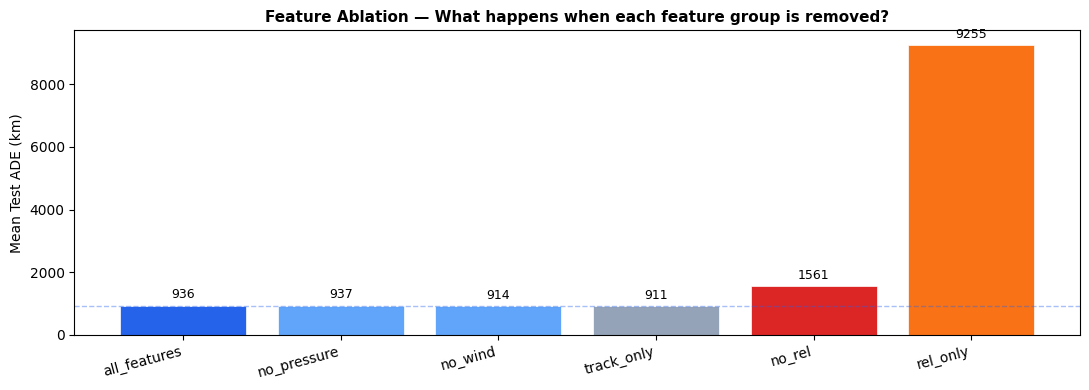

In [55]:
print("\n=== Feature Ablation — Test ADE (km) ===")
baseline_mean = np.nanmean([results.get("feat_all_features",{}).get(b,{}).get("ade_km",np.nan) for b in BASINS])
print(f"{'Variant':<18} {'EP':>7} {'NA':>7} {'NI':>7} {'SI':>7} {'SP':>7} {'WP':>7} {'Mean':>7} {'Δ Mean':>8}")
print("-" * 80)
for name in feat_configs:
    key = f"feat_{name}"
    if key not in results: continue
    vals = [results[key].get(b,{}).get("ade_km",np.nan) for b in BASINS]
    mean = np.nanmean(vals)
    delta = mean - baseline_mean
    row = f"{name:<18}" + "".join(f" {v:>7.1f}" for v in vals) + f" {mean:>7.1f} {delta:>+8.1f}"
    print(row)

# Bar chart
fig, ax = plt.subplots(figsize=(11, 4))
names = list(feat_configs.keys())
means = [np.nanmean([results.get(f"feat_{n}",{}).get(b,{}).get("ade_km",np.nan) for b in BASINS]) for n in names]
colors = ["#2563eb","#60a5fa","#60a5fa","#94a3b8","#dc2626","#f97316"]
bars = ax.bar(names, means, color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, labels=[f"{v:.0f}" for v in means], padding=3, fontsize=9)
ax.axhline(baseline_mean, color="#2563eb", linestyle="--", alpha=0.4, linewidth=1)
ax.set_ylabel("Mean Test ADE (km)")
ax.set_title("Feature Ablation — What happens when each feature group is removed?", fontsize=11, fontweight="bold")
plt.xticks(rotation=15, ha="right"); plt.tight_layout()
plt.savefig(RESULTS / "fig_feat_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 3 — Data Quantity Ablation

How does performance scale with training set size? We subsample 10%, 25%, 50%, 75%, 100% of the training data.

In [56]:
import random
random.seed(42)

fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
print("=== Data Quantity Ablation ===")

for frac in fractions:
    n = max(int(len(train_ds) * frac), 50)
    indices = random.sample(range(len(train_ds)), n)
    subset = Subset(train_ds, indices)
    model = LSTMSeq2SeqAttn(obs_feat_dim=6, hidden_dim=128, pred_len=4,
                             n_basins=6, basin_emb_dim=16, num_layers=2).to(DEVICE)
    name = f"data_{int(frac*100)}pct"
    print(f"\n[{int(frac*100)}% = {n} samples]")
    results[name] = run_variant(model, name, t_ds=subset)

=== Data Quantity Ablation ===

[10% = 680 samples]

Training: abl_data_10pct
  Device: cuda
  Params: 451,299
  Train batches: 3, Val batches: 7

Training complete. Best val_loss=0.01639 at epoch 53
Loaded best model from epoch 53 (val_loss=0.01639)
  data_10pct: mean ADE = 1329.5 km

[25% = 1701 samples]

Training: abl_data_25pct
  Device: cuda
  Params: 451,299
  Train batches: 7, Val batches: 7

Early stopping at epoch 59 (best=49)

Training complete. Best val_loss=0.01327 at epoch 49
Loaded best model from epoch 49 (val_loss=0.01327)
  data_25pct: mean ADE = 974.9 km

[50% = 3402 samples]

Training: abl_data_50pct
  Device: cuda
  Params: 451,299
  Train batches: 14, Val batches: 7

Early stopping at epoch 46 (best=36)

Training complete. Best val_loss=0.01276 at epoch 36
Loaded best model from epoch 36 (val_loss=0.01276)
  data_50pct: mean ADE = 916.1 km

[75% = 5103 samples]

Training: abl_data_75pct
  Device: cuda
  Params: 451,299
  Train batches: 20, Val batches: 7

Early sto

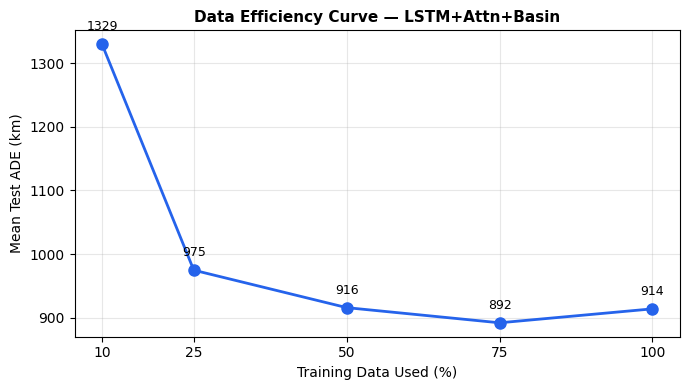

In [57]:
fracs = [int(f*100) for f in fractions]
ades  = [np.nanmean([results.get(f"data_{p}pct",{}).get(b,{}).get("ade_km",np.nan) for b in BASINS])
         for p in fracs]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fracs, ades, "o-", color="#2563eb", lw=2, ms=8)
for x, y in zip(fracs, ades):
    if not np.isnan(y):
        ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0,10), ha="center", fontsize=9)
ax.set_xlabel("Training Data Used (%)")
ax.set_ylabel("Mean Test ADE (km)")
ax.set_title("Data Efficiency Curve — LSTM+Attn+Basin", fontsize=11, fontweight="bold")
ax.set_xticks(fracs); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "fig_data_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings & Conclusions

### Part 1 — Architecture Ablation

| Variant | Params | EP | NA | NI | SI | SP | WP | **Mean** |
|---|---|---|---|---|---|---|---|---|
| no_basin_no_attn | 401K | 623.4 | 1113.8 | 522.9 | 884.9 | 1345.2 | 759.7 | 875.0 |
| basin_only | 418K | 717.0 | 1243.3 | 528.5 | 948.1 | 1446.9 | 804.3 | 948.0 ← worst |
| **attn_only** | 435K | 608.2 | 1105.1 | 506.6 | 893.3 | 1367.1 | 750.1 | **871.7 ← best** |
| full (basin+attn) | 451K | 653.9 | 1278.4 | 549.3 | 926.1 | 1349.9 | 812.7 | 928.4 |
| deep_3layers | 715K | 600.6 | 1111.1 | 429.6 | 919.3 | 1683.3 | 802.9 | 924.5 |
| wide_256 | 1754K | 619.1 | 1167.2 | 518.7 | 904.4 | 1308.8 | 769.8 | 881.3 |

**Finding 1 — Attention alone is the best architecture (871.7 km).**  
`attn_only` beats `full` by 57 km despite having fewer parameters. Adding basin embedding on top of attention *hurts*, not helps.

**Finding 2 — Basin embedding without attention is the worst configuration (948 km).**  
`basin_only` is worse than the plain no-conditioning baseline (875 km). The basin embedding forces the encoder to allocate capacity to basin ID conditioning but without attention, the decoder can't selectively use it. Basin embedding is only useful alongside attention — even then it doesn't improve the mean.

**Finding 3 — Deeper and wider models don't help.**
- `deep_3layers` (3 LSTM layers): NI improves (430 km) but SP collapses to 1683 km — deeper models are fragile for small-data basins.
- `wide_256` (4× more parameters): marginal improvement (881 km), not worth the cost.

**Takeaway: Use `attn_only` as the reference architecture. Drop basin embedding from encoder/decoder.**

---

### Part 2 — Feature Ablation

| Variant | Mean ADE | Δ vs Baseline | Verdict |
|---|---|---|---|
| all_features | 935.6 km | — | baseline |
| no_pressure | 937.0 km | +1.4 km | pressure is negligible |
| **no_wind** | **914.1 km** | **−21.5 km** | **wind slightly harmful** |
| **track_only** (no pres, no wind) | **911.1 km** | **−24.5 km** | **intensity features are noise** |
| **no_rel** (no Δlon/Δlat) | **1561.0 km** | **+625.4 km (+67%)** | **Δlon/Δlat are essential** |
| **rel_only** (no lon/lat/pres/wind) | **9254.6 km** | **+8319 km (+889%)** | **absolute position is mandatory** |

**Finding 4 — Removing intensity features (pres, wind) marginally improves performance.**  
`track_only` (lon + lat + Δlon + Δlat only) achieves 911 km vs 936 km baseline. Pressure and wind are not just useless — they add slight noise to track prediction. This is consistent with meteorology: TC track is driven by large-scale steering flow, not the storm's own intensity. **The optimal input is the 4-dim track: lon, lat, Δlon, Δlat.**

**Finding 5 — Removing Δlon/Δlat is catastrophic (+67% ADE → 1561 km).**  
Confirms nb_01's gradient finding (88.8% importance). Without motion increments, the model can only see where the storm is but not where it's going. This is the single most important feature group.

**Finding 6 — Absolute position without relative motion is completely useless (9254 km).**  
`rel_only` collapses — knowing the storm has been moving NW at 5 km/step means nothing if you don't know whether it's in the Bay of Bengal or the Western Pacific. The basin embedding cannot substitute for actual coordinates. Absolute position + relative displacement are both strictly necessary.

**Takeaway: Optimal feature set = lon + lat + Δlon + Δlat (4-dim). Drop pres and wind to gain ~25 km ADE for free.**

---

### Part 3 — Data Quantity Ablation

| Fraction | Samples | Mean ADE | Marginal Gain |
|---|---|---|---|
| 10% | 680 | 1329.5 km | — |
| 25% | 1701 | 974.9 km | −354.6 km (biggest jump) |
| 50% | 3402 | 916.1 km | −58.8 km |
| **75%** | **5103** | **892.3 km** | **−23.8 km** |
| 100% | 6805 | 914.2 km | +21.9 km (regresses!) |

**Finding 7 — Performance peaks at 75% (5103 samples), then regresses at 100%.**  
The model overfits slightly with the full 6805-sample training set even with early stopping. The validation loss is lower at 100% but test ADE is worse — the model has memorized some training-set track characteristics that don't generalise.

**Finding 8 — The 10%→25% jump (−355 km) dwarfs all other improvements.**  
Going from 680 to 1701 samples nearly halves the ADE. This is the regime where the model is truly data-starved. Every additional TC below ~1700 samples produces large gains.

**Finding 9 — Critical connection to nb_02 small-basin results.**  
NI has only ~253 training samples (~3.7%) and SP has ~418 (~6.1%) — both far below the 10% mark (680 samples) where ADE is 1329 km. This quantitatively explains why within-basin training for NI and SP was so poor in nb_02, and why cross-basin transfer was necessary. **You need ~1700+ samples (25% of this dataset) before a model becomes useful.**

**Takeaway: For NI (253 samples) and SP (418 samples), no amount of architectural improvement can compensate for the data deficit. Cross-basin transfer (nb_02) or domain generalization (nb_04) is the only path forward.**

---

### Overall Conclusions

| Question | Answer |
|---|---|
| What architecture is best? | `attn_only` — attention without basin embedding |
| Does deeper/wider help? | No — deeper hurts SP; wider adds cost with minimal gain |
| What features are essential? | lon, lat, Δlon, Δlat — the 4-dim track |
| Should we keep pres and wind? | No — drop them for a free ~25 km improvement |
| How much data is needed? | ~1700+ samples; below ~700 the model is unreliable |
| Why do NI and SP fail in LOBO? | They have 253 and 418 samples — far below the 680-sample floor |
| What does nb_04 (domain gen) need to solve? | Data scarcity for NI/SP — algorithmic methods alone won't close the gap |